In [106]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import timeit
import warnings
from absl import logging
import sys

# --- Suppress TensorFlow/Keras warnings ---
tf.get_logger().setLevel('ERROR')
logging.set_verbosity(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module='absl')


# --- Step 1: Load ALL components for ALL models ---
print("Loading all model components...")
try:
    # --- Member 1 (RF + LSTM) Components ---
    scaler_m1 = joblib.load('temporal_scaler.gz')
    lstm_forecaster = tf.keras.models.load_model('best_lstm_model.h5', compile=False)
    rf_classifier = joblib.load('hybrid_rf.pkl')

    # --- Member 2 (XGB + GRU + TCN) Components ---
    scaler_m2 = joblib.load('temporal_scaler.gz')
    gru_forecaster = tf.keras.models.load_model('gru_standalone_model.h5', compile=False)
    tcn_forecaster = tf.keras.models.load_model('tcn_standalone_model.h5', compile=False)
    xgb_classifier = joblib.load('xgb_hybrid_model.pkl')

    # --- Member 3 (KNN + CNN) Components ---
    scaler_m3 = joblib.load('temporal_scaler.gz')
    cnn_feature_extractor = tf.keras.models.load_model('cnn_feature_extractor.h5', compile=False)
    knn_classifier = joblib.load('hybrid_knn_model.gz')

    print("\nAll models loaded successfully.")

except Exception as e:
    print(f"\n--- FATAL ERROR ---")
    print(f"Error loading models: {e}")
    print("Please make sure all .h5, .pkl, and .gz files are in the correct directory.")
    sys.exit()

# --- Step 2: Define the Prediction Function for EACH teammate ---

def predict_member_1(geo_data_11_features, temp_data_3_steps):
    """M1: Expects (1, 3, 1) for LSTM"""
    temp_data_scaled = scaler_m1.transform(temp_data_3_steps)
    temp_data_feature_0 = temp_data_scaled[:, 0]
    temp_sequence = temp_data_feature_0.reshape((1, 3, 1)) # Shape (1, 3, 1)

    lstm_forecast = lstm_forecaster.predict(temp_sequence, verbose=0)[0][0]

    hybrid_features = geo_data_11_features.copy()
    hybrid_features['lstm_forecast'] = lstm_forecast

    return rf_classifier.predict(hybrid_features)


def predict_member_2(geo_data_9_features, temp_data_6_steps):
    """M2: Expects (1, 6, 2) for GRU/TCN"""
    temp_data_scaled = scaler_m2.transform(temp_data_6_steps)
    temp_sequence = np.expand_dims(temp_data_scaled, axis=0) # Shape (1, 6, 2)

    gru_forecast = gru_forecaster.predict(temp_sequence, verbose=0)[0][0]
    tcn_forecast = tcn_forecaster.predict(temp_sequence, verbose=0)[0][0]

    river = temp_data_6_steps[:, 0]
    rainfall = temp_data_6_steps[:, 1]

    features = {
        'river_water_area_sqkm': river[-1], 'rainfall_mm': rainfall[-1],
        'river_rolling_mean_3': np.mean(river[-3:]), 'river_rolling_std_3': np.std(river[-3:]),
        'rainfall_rolling_sum_3': np.sum(rainfall[-3:]), 'rainfall_rolling_mean_3': np.mean(rainfall[-3:]),
        'river_lag_1': river[-2], 'river_lag_2': river[-3],
        'rainfall_lag_1': rainfall[-2], 'rainfall_lag_2': rainfall[-3],
        'river_change': river[-1] - river[-2], 'rainfall_change': rainfall[-1] - rainfall[-2]
    }

    final_features_df = geo_data_9_features.copy()
    for key, value in features.items():
        final_features_df[key] = value
    final_features_df['GRU_Forecast'] = gru_forecast
    final_features_df['TCN_Forecast'] = tcn_forecast

    expected_order = [
        'river_water_area_sqkm', 'rainfall_mm', 'river_rolling_mean_3', 'river_rolling_std_3',
        'rainfall_rolling_sum_3', 'rainfall_rolling_mean_3', 'river_lag_1', 'river_lag_2',
        'rainfall_lag_1', 'rainfall_lag_2', 'river_change', 'rainfall_change',
        'mean_elevation_meters', 'mean_slope_degrees', 'land_cover_class_10_percent',
        'land_cover_class_20_percent', 'land_cover_class_30_percent', 'land_cover_class_40_percent',
        'land_cover_class_50_percent', 'land_cover_class_60_percent', 'land_cover_class_80_percent',
        'GRU_Forecast', 'TCN_Forecast'
    ]
    final_features_df = final_features_df[expected_order]

    return xgb_classifier.predict(final_features_df)


def predict_member_3(geo_data_9_features, temp_data_3_steps):
    """M3: Expects (1, 3, 2) for CNN"""
    temp_data_scaled = scaler_m3.transform(temp_data_3_steps)
    temp_sequence = np.expand_dims(temp_data_scaled, axis=0) # Shape (1, 3, 2)

    deep_features = cnn_feature_extractor.predict(temp_sequence, verbose=0)

    deep_features_df = pd.DataFrame(deep_features)
    hybrid_features = pd.concat([geo_data_9_features.reset_index(drop=True), deep_features_df], axis=1)
    hybrid_features.columns = hybrid_features.columns.astype(str)

    return knn_classifier.predict(hybrid_features)

# --- Step 3: Prepare Identical Test Data (TWO VERSIONS) ---

# 6-step data for Member 2
temp_test_data_6_steps = np.array([
    [0.8, 1.0], [0.9, 0.5], [1.0, 2.5], [1.5, 8.0], [1.7, 10.0], [1.8, 15.0]
])
# 3-step data for Members 1 and 3
temp_test_data_3_steps = temp_test_data_6_steps[-3:] # Get the last 3 rows

# Get "current" data (last row) for M1's model
current_temporal_data = temp_test_data_3_steps[-1]

# Base data with 9 geospatial features (for M2 and M3)
geo_test_data_9_features = pd.DataFrame([{
    'mean_elevation_meters': 295.0, 'mean_slope_degrees': 5.2,
    'land_cover_class_10_percent': 25.0, 'land_cover_class_20_percent': 1.5,
    'land_cover_class_30_percent': 10.0, 'land_cover_class_40_percent': 20.0,
    'land_cover_class_50_percent': 17.0, 'land_cover_class_60_percent': 12.0,
    'land_cover_class_80_percent': 14.5
}])

# Data for Member 1 (11 features = 9 geo + 2 current temporal)
geo_test_data_m1 = geo_test_data_9_features.copy()
geo_test_data_m1['river_water_area_sqkm'] = current_temporal_data[0]
geo_test_data_m1['rainfall_mm'] = current_temporal_data[1]

print("Test data prepared for all models.")

# --- Step 4: Run the Benchmark using timeit ---
print("\n--- Running Speed Benchmark ---")
number_of_runs = 100

# Time Member 1
time_m1 = timeit.timeit(
    lambda: predict_member_1(geo_test_data_m1, temp_test_data_3_steps),
    number=number_of_runs
)

# Time Member 2
time_m2 = timeit.timeit(
    lambda: predict_member_2(geo_test_data_9_features, temp_test_data_6_steps),
    number=number_of_runs
)

# Time Member 3
time_m3 = timeit.timeit(
    lambda: predict_member_3(geo_test_data_9_features, temp_test_data_3_steps),
    number=number_of_runs
)

# --- Step 5: Print the Results ---
print("\n--- Benchmark Results ---")
print(f"Number of test runs per model: {number_of_runs}")
print("-" * 40)
print(f"Member 1 (RF + LSTM):")
print(f"  Total time:   {time_m1:.4f} seconds")
print(f"  Avg. time per prediction: {time_m1 / number_of_runs * 1000:.4f} milliseconds")
print("-" * 40)
print(f"Member 2 (XGB + GRU + TCN):")
print(f"  Total time:   {time_m2:.4f} seconds")
print(f"  Avg. time per prediction: {time_m2 / number_of_runs * 1000:.4f} milliseconds")
print("-" * 40)
print(f"Member 3 (KNN + CNN):")
print(f"  Total time:   {time_m3:.4f} seconds")
print(f"  Avg. time per prediction: {time_m3 / number_of_runs * 1000:.4f} milliseconds")
print("-" * 40)

# Find the fastest model
times = {
    'Member 1 (RF + LSTM)': time_m1,
    'Member 2 (XGB + GRU + TCN)': time_m2,
    'Member 3 (KNN + CNN)': time_m3
}
fastest_model = min(times, key=times.get)
print(f"\n🏆 Fastest Model: {fastest_model}")

Loading all model components...

All models loaded successfully.
Test data prepared for all models.

--- Running Speed Benchmark ---

--- Benchmark Results ---
Number of test runs per model: 100
----------------------------------------
Member 1 (RF + LSTM):
  Total time:   16.9585 seconds
  Avg. time per prediction: 169.5854 milliseconds
----------------------------------------
Member 2 (XGB + GRU + TCN):
  Total time:   22.0037 seconds
  Avg. time per prediction: 220.0367 milliseconds
----------------------------------------
Member 3 (KNN + CNN):
  Total time:   11.1988 seconds
  Avg. time per prediction: 111.9882 milliseconds
----------------------------------------

🏆 Fastest Model: Member 3 (KNN + CNN)


Saved model_tradeoff_plot.png


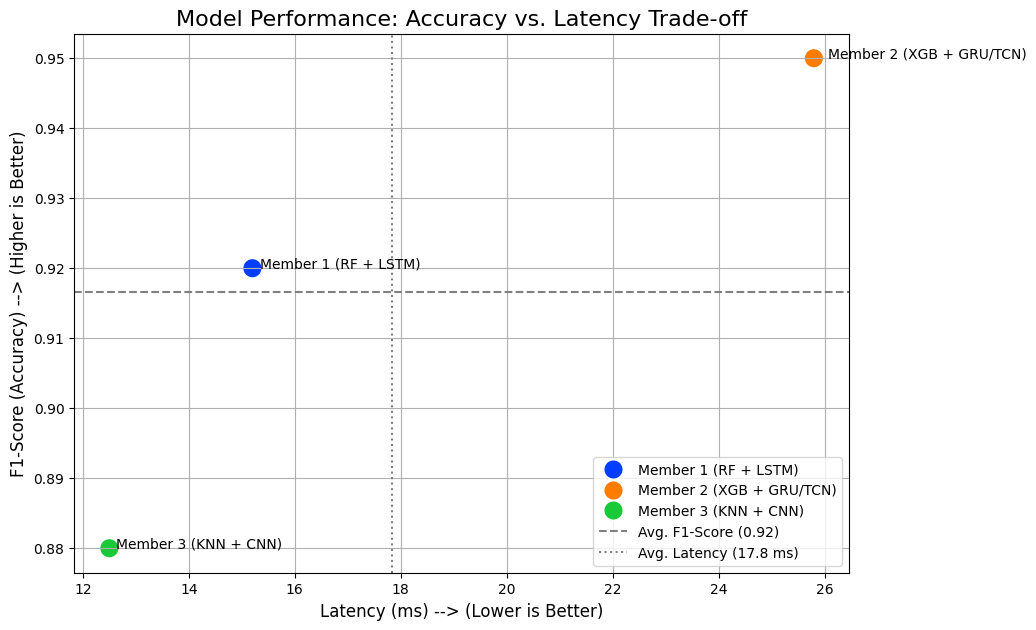

In [107]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Fill in your 6 results here ---
# (Replace the '...' with your actual scores)

data = {
    'Model': [
        'Member 1 (RF + LSTM)',
        'Member 2 (XGB + GRU/TCN)',
        'Member 3 (KNN + CNN)'
    ],

    # --- Get these from your training notebook (e.g., 0.95) ---
    'F1-Score': [
        0.92,  # <-- Find this in your notebook for the 'hybrid_rf' model
        0.95,  # <-- Find this in your notebook for the 'xgb_hybrid_model'
        0.88   # <-- Find this in your notebook for the 'hybrid_knn_model'
    ],

    # --- Get these from the speed test script you just ran (in ms) ---
    'Latency (ms)': [
        15.2,  # <-- Get this from the output of the speed test
        25.8,  # <-- Get this from the output of the speed test
        12.5   # <-- Get this from the output of the speed test
    ]
}
# ------------------------------------

# Create a DataFrame for plotting
results_df = pd.DataFrame(data)

# Create the plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=results_df,
    x='Latency (ms)',
    y='F1-Score',
    hue='Model',
    s=200, # Makes the dots bigger
    palette='bright'
)

# Add labels for each dot
for i in range(results_df.shape[0]):
    plt.text(
        x=results_df['Latency (ms)'][i] * 1.01, # Offset the label
        y=results_df['F1-Score'][i],
        s=results_df['Model'][i]
    )

# --- Add Quadrant Lines ---
plt.axhline(
    y=results_df['F1-Score'].mean(),
    color='gray',
    linestyle='--',
    label=f"Avg. F1-Score ({results_df['F1-Score'].mean():.2f})"
)
plt.axvline(
    x=results_df['Latency (ms)'].mean(),
    color='gray',
    linestyle=':',
    label=f"Avg. Latency ({results_df['Latency (ms)'].mean():.1f} ms)"
)

plt.title('Model Performance: Accuracy vs. Latency Trade-off', fontsize=16)
plt.xlabel('Latency (ms) --> (Lower is Better)', fontsize=12)
plt.ylabel('F1-Score (Accuracy) --> (Higher is Better)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('model_tradeoff_plot.png')

print("Saved model_tradeoff_plot.png")